In [ ]:
# runs base code (converting matlab to python)
%%capture
%run "/Users/katbutler/MetabolicCost/metCostMod-Result.ipynb"

In [ ]:
import math

#creates df of subject speeds and activities
analyzed = set()
dfCount = 1
for subject in result.keys():
    indShiftDict = {}
    if subject[0] in analyzed:
        continue
    analyzed.add(subject[0])
    for activity in result.keys():
    
        if activity[1] in indShiftDict:
            continue
            
        if activity[1] not in result[subject[0]]:
            continue

        ind = result[subject[0]][activity[1]]['EMG']['Data'][:, code]
        indShift = np.where((ind[:-1] - ind[1:]) != 0)[0]
        
        
        indShiftDict[activity[1]] = indShift

    # Convert to DataFrame for the subject
    indDF = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in indShiftDict.items()]))
    indDF = indDF.fillna(0)
    indDF = indDF/1000
    indDF = np.ceil(indDF)
    
    if dfCount <= 10:
        if dfCount < 10:
            exec(f"Subject0{dfCount} = indDF")
            dfCount += 1
        else:
            exec(f"Subject{dfCount} = indDF")
            dfCount += 1
    print(indDF)
# print(Subject01)

In [ ]:
# Functions

# pd.set_option("display_max.rows",1920)
# DEFINE DERIVATIVES
import numpy as np

# Time: 0-15
# X: signal with 15 second
# Ver: x_1

def num_derivative(time, x, ver):
    if ver.lower() == 'x_1':
        version = 2
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')
        
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    delta_t = np.mean(np.diff(time))  # sampling time
    W = 4  # window size
    N = 3  # order of polynomial
    K = round(W / 2)  # center node

    if len(x) < W + 1 or np.std(x) < 1e-12:
        return np.zeros_like(x)
    
    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1


    try:
        R = R @ np.linalg.pinv(A.T @ A) @ A.T
    except np.linalg.LinAlgError:
        # Return zero derivative if matrix is singular
        return np.zeros_like(x)


    if version != 3:
        x_d = np.zeros_like(x)
    else:
        x_d = {key: np.zeros_like(val) for key, val in x.items()}

 
    if version == 2:
        for i in range(W - K, len(x) - K):
            segment = x[i - W + K : i + K + 1, 0]
            if np.any(np.isnan(segment)):
                x_d[i, :] = 0.0
            else:
                x_d[i, :] = (R @ segment) / delta_t

    return x_d

import numpy as np
from scipy.signal import convolve

def gaussian_kernel(size, sigma):
    """Create a Gaussian kernel."""
    x = np.linspace(-size // 2, size // 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel)

def filterSignal_Gaussian(signal, fs, cutoff):
    """
    Filter a signal using a Gaussian kernel and compute its derivative
    using the derivative of the Gaussian.
    """
    # Kernel size: 1-minute window at fs Hz
    kernel_size = int(fs * 60)
    if kernel_size % 2 == 0:
        kernel_size += 1  # make it odd for symmetry

    # Convert cutoff frequency to Gaussian std in samples
    sigma = fs / (2 * np.pi * cutoff)

    # Create kernels
    g_kernel = gaussian_kernel(kernel_size, sigma)

    # Filter signal
    filtered = convolve(signal, g_kernel, mode='same')

    return filtered

import scipy.signal as sps

#EMG FILTERING FUNCTION
def emg_filt(raw):
    emg = raw
    fs = 1000.0
    lowcut = 30.0
    highcut = 350.0
    order = 5
    nyquist = 0.5 * fs 
    
    has_nan = "Yes" if np.isnan(emg).any() else "No"
    # print(f"Channel has NaN: {has_nan}")
    
    # Bandpass filter 30-350 Hz
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sps.butter(order, [low, high], btype='bandpass')
    filtered = sps.filtfilt(b, a, emg)
    
    # Full-wave rectification
    rectified = np.abs(filtered)
    
    # Low-pass filter 5 Hz and envelope
    cutoff_lp = 5.0  
    low = cutoff_lp / nyquist
    b_lp, a_lp = sps.butter(4, low, btype='low')
    lowPass = sps.filtfilt(b_lp, a_lp, rectified)
    
    return lowPass

In [47]:
import numpy as np
import pandas as pd
from scipy import signal, interpolate
import warnings
warnings.filterwarnings("ignore")

# DEFINING FILTERING CONSTANTS
fs_ke = 128
fs_emg = 1000.0
fs_deriv = 1000
fs_hr_target = 10
channels = [5, 8, 13, 16]
window_sec = 0.1
samples_per_window = int(window_sec * fs_deriv)
window_sec_hr = 1.0
samples_per_window_hr = int(window_sec_hr * fs_hr_target)

low = 50
high = 150
nyquist = fs_deriv / 2
low_c = low / nyquist
high_c = high / nyquist
order = 4
a_filt, b_filt = signal.butter(order, [low_c, high_c], btype='band')

low_hr = 0.01
high_hr = 0.5
nyquist_hr = fs_hr_target / 2
low_c_hr = low_hr / nyquist_hr
high_c_hr = high_hr / nyquist_hr
order_hr = 2
b_filt_hr, a_filt_hr = signal.butter(order_hr, [low_c_hr, high_c_hr], btype='band')

# Signed RMS function
def rms(signal):
    mag = np.sqrt(np.mean(signal**2))
    direction = np.sign(np.mean(signal))
    return direction * mag

#this was used to test code, ignore
subjects = ('Subject01', 'Backwards')

all_rows = []

print("Processing all subjects and activities...")

subjects = [("Subject01","Backwards")]


for subject in result.keys():
    if subject[0] == "Subject02" and subject[1] in ['Backwards','Backwards2']:
        continue
    if subject[0] == "Subject05" and subject[1] in ['Cycling','Cycling2']:
        continue
    
    print(f"Processing {subject[0]} - {subject[1]}...")
    
    indDF = globals()[subject[0]].astype(int)
    valid_times = indDF[subject[1]][indDF[subject[1]] != 0].reset_index(drop=True)
    
    idx = list(sorted(set([k[0] for k in result.keys()]))).index(subject[0])
    subject_mass = mass[idx]
    mNorm = mass[idx] / 82.2
    
    start_time = 360
    end_time = int(valid_times.iloc[-1])
    
    # ------------------- KE ----------------------------------------
    accel_data = result[subject[0]][subject[1]]['APDM_Accel']['Data']
    
    segments = [
        {'Name': 'W', 'I': 0.02654, 'mass': 0, 'dist': 0, 'columns': [5, 6, 7]},
        {'Name': 'C', 'I': 0.33201, 'mass': 0, 'dist': 0, 'columns': [14, 15, 16]},
        {'Name': 'AL', 'I': 0.06397, 'mass': 0, 'dist': 0, 'columns': [23, 24, 25]},
        {'Name': 'AR', 'I': 0.06271, 'mass': 0, 'dist': 0, 'columns': [32, 33, 34]}
    ]
    
    KE_df = pd.DataFrame()
    
    for segment in segments:
        segment_name = segment['Name']
        I = segment['I'] * mNorm
        cols = segment['columns']
        m = segment['mass']
        r = segment['dist']
        
        x, y, z = [np.nan_to_num(accel_data[:, c], nan=0.0) for c in cols]
        omega = np.sqrt(x**2 + y**2 + z**2)
        KE = 0.5 * (I + (m*(0.5*r)**2)) * omega**2
        KE_df[segment_name] = KE
    
    KE_df['total'] = (KE_df['W'] + KE_df['C'] + KE_df['AL'] + KE_df['AR'])
    KE_df.to_csv('/Users/katbutler/MetabolicCost/kineticenergy.csv', index=False)
    
    #----------------------------EE-------------------------------
    VO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vo2]
    VCO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vco2]
    EE = (16.58 * VO2 + 4.15 * VCO2) / mass[0]
    
    ind = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, code]
    ind = ind[:-1] - ind[1:]
    bool_ind = ind != 0.0
    indShift = np.where(bool_ind)[0]
    indShift = np.concatenate((indShift, [len(ind)]))
    
    eePoints = []
    T_first_phase = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[0], 0]
    timeM3_first = T_first_phase - (3 * 60)
    bool_time_first = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3_first
    threeMin_first = indShift[0] - np.max(np.where(bool_time_first)[0])
    EE_avg_first = np.mean(EE[indShift[0] - threeMin_first:indShift[0]])
    
    for i in range(len(indShift)):
        if i == 0:
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin_first:indShift[i]] - EE_avg_first), 4)))
        elif i == len(indShift) - 1:
            eePoints.append(float(np.round(np.mean(EE[-threeMin_first:] - EE_avg_first), 4)))
        else:
            T = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[i], 0]
            timeM3 = T - (3 * 60)
            bool_time = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3
            threeMin = indShift[i] - np.max(np.where(bool_time)[0])
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin:indShift[i]] - EE_avg_first), 4)))
    
    eePoints = eePoints[1:-1]
    
    #----------------------------HR-------------------------------
    metab_data = result[subject[0]][subject[1]]['Metabolics_System']['Data']
    time_col = metab_data[:, 0]
    hr_col = metab_data[:, 8]
    
    standing_mask = (time_col >= 3 * 60) & (time_col <= 6 * 60)
    standing_avg_hr = np.mean(hr_col[standing_mask])

    
    hr_time_start = time_col[0]
    hr_time_end = time_col[-1]
    time_10hz = np.arange(hr_time_start, hr_time_end, 1.0 / fs_hr_target)
    
    interp_func = interpolate.interp1d(time_col, hr_col, kind='linear', bounds_error=False, fill_value='extrapolate')
    hr_10hz = interp_func(time_10hz)
    
    hr_filtered = signal.filtfilt(b_filt_hr, a_filt_hr, hr_10hz)
    
    #-----------------------------EMG-------------------------------------------
    emg_full = result[subject[0]][subject[1]]['EMG']['Data']
    emg_time = emg_full[:, 0]
    
    emg_channel_data = {}
    emg_deriv_data = {}
    
    for ch in channels:
        emg = np.nan_to_num(emg_full[:, ch], nan=0.0)
        
        lowcut = 30.0
        highcut = 350.0
        order = 5
        nyq = 0.5 * fs_emg
        b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='bandpass')
        filtered = signal.filtfilt(b, a, emg)
        rectified = np.abs(filtered)
        
        cutoff_lp = 5.0
        b_lp, a_lp = signal.butter(4, cutoff_lp / nyq, btype='low')
        lowPass = signal.filtfilt(b_lp, a_lp, rectified)
        emg_channel_data[ch] = lowPass

        signal_filt = np.nan_to_num(emg_filt(emg), nan=0.0)
        emg_deriv_data[ch] = signal_filt
    
    #--------------------------15 SECOND BINS------------------------------------
    num_intervals = len(valid_times) - 1
    samples_per_fifteen = 15 * 128
    bins_per_interval = 24
    
    for i in range(num_intervals):
        interval_start = int(indDF[subject[1]][i]) * 128
        interval_end = int(indDF[subject[1]][i + 1]) * 128
        
        for b in range(bins_per_interval):
            bin_start = interval_start + b * samples_per_fifteen
            bin_end = bin_start + samples_per_fifteen
            
            if bin_end > interval_end:
                break
            
            row_data = {
                'Subject': subject[0],
                'Activity': subject[1],
                'Time': bin_start / 128,
                'Weight': subject_mass
            }
            
            mean_val = round(KE_df['total'].iloc[bin_start:bin_end].mean(), 4)
            row_data['KE'] = mean_val
            
            row_data['EE'] = eePoints[i]
            
            bin_start_sec = bin_start / 128
            bin_end_sec = bin_end / 128
            mask = (time_col >= bin_start_sec) & (time_col < bin_end_sec)
            row_data['HR'] = float(np.round(np.mean(hr_col[mask]) - standing_avg_hr, 4))
            
            # HR Derivative
            start_idx_hr = int(bin_start_sec * fs_hr_target)
            end_idx_hr = int(bin_end_sec * fs_hr_target)
            deriv_values_hr = []
            
            for window_start in range(start_idx_hr, end_idx_hr, samples_per_window_hr):
                window_end = min(window_start + samples_per_window_hr, end_idx_hr)
                sig_bin_hr = hr_filtered[window_start:window_end]
                t_bin_local_hr = np.arange(len(sig_bin_hr)) / fs_hr_target
                deriv = num_derivative(t_bin_local_hr, sig_bin_hr, 'x_1')
                deriv = deriv.flatten()
                deriv_values_hr.append(deriv.mean())
            
            row_data['HRDeriv'] = (rms(np.array(deriv_values_hr)))
            
            # EMG
            start_idx_emg = int(bin_start_sec * fs_emg)
            end_idx_emg = int(bin_end_sec * fs_emg)
            
            for ch in channels:
                seg = emg_channel_data[ch][start_idx_emg:end_idx_emg]
                row_data[f'EMG{ch}'] = float(np.round(np.mean(seg), 4))
            
            
            all_rows.append(row_data)

# ---------------------------- FINAL DF ------------------------------------
print("\nCreating final dataframe...")
merged_df = pd.DataFrame(all_rows)

# Reorder columns
wanted_cols = ['Subject', 'Activity', 'Time', 'KE', 'HR', 'HRDeriv', 'EE', 'Weight', 
               'EMG5', 'EMG8', 'EMG13', 'EMG16', ]
final_cols = [col for col in wanted_cols if col in merged_df.columns]
merged_df = merged_df[final_cols]

Processing all subjects and activities...


AttributeError: 'MixedLMResults' object has no attribute 'keys'

In [48]:
#saves to csv so that you dont need to rerun the long code
print(merged_df.head(5000))
merged_df.to_csv('/Users/katbutler/MetabolicCost/merged.csv', index=False)

NameError: name 'merged_df' is not defined

In [ ]:
merged_df_train = merged_df.copy()

# Drop all EMG derivative columns
emg_derivs = ['EMG5Deriv', 'EMG8Deriv', 'EMG13Deriv', 'EMG16Deriv']
merged_df_train = merged_df_train.drop(columns=emg_derivs)

# Rename EMG columns to new names
merged_df_train = merged_df_train.rename(columns={
    'EMG5': 'rsol',
    'EMG8': 'rbf',
    'EMG13': 'lsol',
    'EMG16': 'lbf'
})

# Check the result
print(merged_df_train.head())


In [ ]:
#this was used to verify hr derivatives, ignore
subject1Walk = merged_df[(merged_df['Subject'] == 'Subject01') & (merged_df['Activity'] == 'Walking')]

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('HR')
ax1.plot(subject1Walk['Time'], subject1Walk['HR'],'.',color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('HRDeriv')
ax2.plot(subject1Walk['Time'],subject1Walk['HRDeriv'],'.', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.xlabel('Time (s)')
plt.title('HR vs. EE Ground')
plt.show()

In [151]:
#saves training dataframe
merged_df_train.to_pickle("/Users/katbutler/MetabolicCost/merged_df_train.pkl")

NameError: name 'merged_df_train' is not defined

In [181]:
import pandas as pd

#reads dataframe and adds emg signals
merged_df_train = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_df_train_v2.pkl")

for col in ['rsol', 'rbf', 'lsol', 'lbf']:
    merged_df_train[col] = merged_df_train[col] / merged_df_train[col].max()

merged_df_train['right'] = merged_df_train['rsol'] + merged_df_train['rbf']
merged_df_train['left'] = merged_df_train['lsol'] + merged_df_train['lbf']

Tuning subject: Subject01

--- Hyperparameter Tuning Results ---
Best Kernel: linear
Best C: 0.046
Test Subject: Subject09
     Average Error (Bias): 0.0625
     Train RMSE: 1.0866 , Test RMSE: 0.8483
     Train Normalized RMSE: 0.0751, Test Normalized RMSE: 0.0587
     Train R²:  0.8792 , Test R²:  0.9257

Test Subject: Subject03
     Average Error (Bias): -0.2342
     Train RMSE: 1.0415 , Test RMSE: 1.1644
     Train Normalized RMSE: 0.0720, Test Normalized RMSE: 0.0805
     Train R²:  0.8886 , Test R²:  0.8618

Test Subject: Subject08
     Average Error (Bias): 0.3053
     Train RMSE: 1.0842 , Test RMSE: 0.8163
     Train Normalized RMSE: 0.0750, Test Normalized RMSE: 0.0565
     Train R²:  0.8837 , Test R²:  0.9031

Test Subject: Subject07
     Average Error (Bias): 0.1506
     Train RMSE: 1.0031 , Test RMSE: 1.4466
     Train Normalized RMSE: 0.0750, Test Normalized RMSE: 0.1082
     Train R²:  0.8917 , Test R²:  0.8378

Test Subject: Subject06
     Average Error (Bias): -0.3968
 

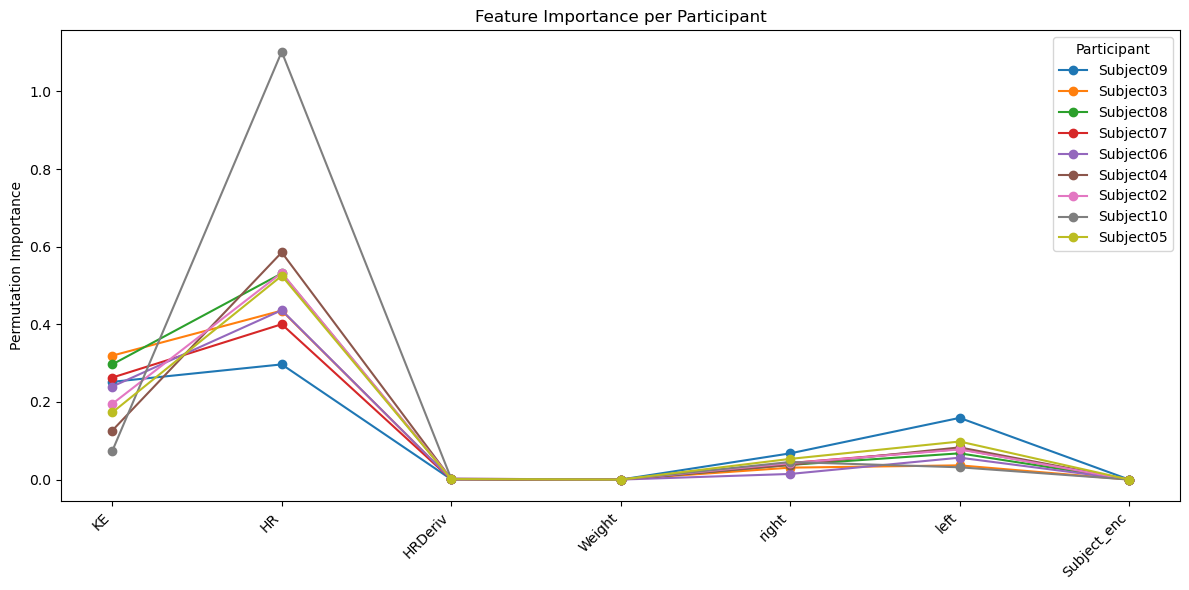

In [233]:
# creates machine learning model
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

LR_df = merged_df_train.copy()
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'HRDeriv','EE', 'Weight', 'right', 'left']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]
uniqueSubjects = np.unique(subjects)


tune_subject = uniqueSubjects[0]  
print(f"Tuning subject: {le.inverse_transform([tune_subject])[0]}")

tune_mask = subjects == tune_subject
X_tune = x[tune_mask]
y_tune = y[tune_mask]
groups_tune = subjects[tune_mask]

pipe = make_pipeline(
    StandardScaler(),
    SVR()
)

param_distributions = {
    "svr__kernel": ["linear", "rbf"],
    "svr__C": np.logspace(-3, 3, 20),
    "svr__gamma": ["scale", "auto"]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=30,
    cv=2,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

search.fit(X_tune, y_tune, groups=groups_tune)

best_params = search.best_params_
best_kernel = best_params["svr__kernel"]
best_C = best_params["svr__C"]
best_gamma = best_params.get("svr__gamma", None)

print("\n--- Hyperparameter Tuning Results ---")
print(f"Best Kernel: {best_kernel}")
print(f"Best C: {best_C}")
if best_kernel == "rbf":
    print(f"Best gamma: {best_gamma}")


final_mask = subjects != tune_subject
X_final = x[final_mask]
y_final = y[final_mask]
subjects_final = subjects[final_mask]
original_subjects_final = original_subject_labels[final_mask]

if best_kernel == "linear":
    model = make_pipeline(
        StandardScaler(),
        SVR(kernel="linear", C=best_C)
    )
else:  
    model = make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=best_C, gamma=best_gamma)
    )


gkf = GroupKFold(n_splits=len(np.unique(subjects_final)))

mseTrain, RMSETrain, mseTest, RMSETest, r2train, r2test, normRMSETrain, normRMSETest = [], [], [], [], [], [], [], []
biasTest = []
fold_feature_importance = []
fold_subjects = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_final, y_final, groups=subjects_final), start=1):
    x_train, x_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]

    test_subject = np.unique(original_subjects_final[test_idx])[0]
    fold_subjects.append(test_subject)

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)


    fold_errors_test = y_testPred - y_test
    fold_bias_test = np.mean(fold_errors_test)

    max_train, min_train = y_train.max(), y_train.min()
    max_test, min_test = y_test.max(), y_test.min()

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_RMSE_train = fold_mse_train ** 0.5
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_RMSE_test = fold_mse_test ** 0.5
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)
    foldNormRMSETrain = fold_RMSE_train / (max_train - min_train)
    foldNormRMSETest = fold_RMSE_test / (max_train - min_train)


    mseTrain.append(fold_mse_train)
    RMSETrain.append(fold_RMSE_train)
    mseTest.append(fold_mse_test)
    RMSETest.append(fold_RMSE_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)
    normRMSETrain.append(foldNormRMSETrain)
    normRMSETest.append(foldNormRMSETest)
    biasTest.append(fold_bias_test) 


    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)


    print(f"Test Subject: {test_subject}")
    print(f"     Average Error (Bias): {fold_bias_test:.4f}")
    print(f"     Train RMSE: {fold_RMSE_train:.4f} , Test RMSE: {fold_RMSE_test:.4f}")
    print(f"     Train Normalized RMSE: {foldNormRMSETrain:.4f}, Test Normalized RMSE: {foldNormRMSETest:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}\n")


print("\n--- OVERALL PERFORMANCE SUMMARY ---")
print(f"Average Test Bias (Mean Error): {np.mean(biasTest):.4f}")
print(f"Average Test Error Std Dev:     {np.std(biasTest):.4f}")
print(f"Average RMSE Train: {np.mean(RMSETrain):.4f} , Average RMSE Test: {np.mean(RMSETest):.4f}")
print(f"Average Train Normalized RMSE: {np.mean(normRMSETrain):.4f} , Test Normalized RMSE: {np.mean(normRMSETest):.4f}")
print(f"Average R² Train: {np.mean(r2train):.4f} , Average R² Test: {np.mean(r2test):.4f}")


fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()

In [6]:
# model optimization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# --- DATA PREPARATION ---
LR_df = merged_df_train.copy()
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject', 'KE', 'HR', 'HRDeriv', 'EE', 'Weight', 'right', 'left']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]
uniqueSubjects = np.unique(subjects)

# --- SELECTING THE BEST ARCHITECTURE ---
tune_subject = uniqueSubjects[0]
print(f"Selecting best model architecture using subject: {le.inverse_transform([tune_subject])[0]}")

tune_mask = subjects == tune_subject
X_tune, y_tune = x[tune_mask], y[tune_mask]

# Define the models and their specific hyperparameter grids
model_search_configs = [
    {
        "name": "SVR",
        "estimator": SVR(),
        "params": {
            "model__kernel": ["linear", "rbf"],
            "model__C": np.logspace(-3, 2, 10),
            "model__gamma": ["scale", "auto"]
        }
    },
    {
        "name": "RandomForest",
        "estimator": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5]
        }
    },
    {
        "name": "XGBoost",
        "estimator": XGBRegressor(objective='reg:squarederror', random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__learning_rate": [0.01, 0.1, 0.2],
            "model__max_depth": [3, 6, 9]
        }
    }
]

best_overall_rmse = float('inf')
winner_pipeline = None
winner_name = ""

for config in model_search_configs:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', config["estimator"])
    ])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=config["params"],
        n_iter=15,
        cv=2,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_tune, y_tune)
    current_rmse = abs(search.best_score_)
    print(f"   > {config['name']} Optimized RMSE: {current_rmse:.4f}")
    
    if current_rmse < best_overall_rmse:
        best_overall_rmse = current_rmse
        winner_pipeline = search.best_estimator_
        winner_name = config["name"]

print(f"\n BEST ARCHITECTURE: {winner_name}")
print(f"Best Parameters: {winner_pipeline.named_steps['model'].get_params()}")

# --- CROSS-VALIDATION WITH THE BEST MODEL ---
final_mask = subjects != tune_subject
X_final = x[final_mask]
y_final = y[final_mask]
subjects_final = subjects[final_mask]
original_subjects_final = original_subject_labels[final_mask]

gkf = GroupKFold(n_splits=len(np.unique(subjects_final)))

results = []
fold_feature_importance = []
fold_subjects = []

print("\n--- Starting Leave-One-Subject-Out Validation ---")

for train_idx, test_idx in gkf.split(X_final, y_final, groups=subjects_final):
    x_train, x_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]
    
    test_subject = np.unique(original_subjects_final[test_idx])[0]
    fold_subjects.append(test_subject)


    winner_pipeline.fit(x_train, y_train)
    y_pred = winner_pipeline.predict(x_test)

    # Metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    bias = np.mean(y_pred - y_test)
    
    results.append({'Subject': test_subject, 'RMSE': rmse, 'R2': r2, 'Bias': bias})
    
    # Feature Importance
    perm = permutation_importance(winner_pipeline, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm.importances_mean)
    
    print(f"Subject: {test_subject} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# --- RESULTS & VISUALIZATION ---
results_df = pd.DataFrame(results)
print("\n--- FINAL PERFORMANCE SUMMARY ---")
print(results_df[['RMSE', 'R2', 'Bias']].mean())

# Feature Importance Plot
fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)
plt.figure(figsize=(10, 5))
sns.boxplot(data=fi_df, palette="viridis")
plt.title(f"Feature Importance Stability across Subjects ({winner_name})")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

NameError: name 'merged_df_train' is not defined

In [7]:
# more model optimization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor

# --- DATA PREPARATION ---
LR_df = merged_df_train.copy()
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject', 'KE', 'HR', 'HRDeriv', 'EE', 'Weight', 'right', 'left']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]
uniqueSubjects = np.unique(subjects)

# --- SELECTING THE BEST ARCHITECTURE ---
tune_subject = uniqueSubjects[0]
print(f"Selecting best model architecture using subject: {le.inverse_transform([tune_subject])[0]}")

tune_mask = subjects == tune_subject
X_tune, y_tune = x[tune_mask], y[tune_mask]

# Define the models and their specific hyperparameter grids
model_search_configs = [
{
        "name": "ElasticNet",
        "estimator": ElasticNet(),
        "params": {
            "model__alpha": np.logspace(-4, 1, 10),
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    },
    {
        "name": "KNN",
        "estimator": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 11, 21],
            "model__weights": ["uniform", "distance"]
        }
    },
]

best_overall_rmse = float('inf')
winner_pipeline = None
winner_name = ""

for config in model_search_configs:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', config["estimator"])
    ])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=config["params"],
        n_iter=15,
        cv=2,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_tune, y_tune)
    current_rmse = abs(search.best_score_)
    print(f"   > {config['name']} Optimized RMSE: {current_rmse:.4f}")
    
    if current_rmse < best_overall_rmse:
        best_overall_rmse = current_rmse
        winner_pipeline = search.best_estimator_
        winner_name = config["name"]

print(f"\ BEST ARCHITECTURE: {winner_name}")
print(f"Best Parameters: {winner_pipeline.named_steps['model'].get_params()}")

# --- CROSS-VALIDATION WITH THE WINNING MODEL ---
final_mask = subjects != tune_subject
X_final = x[final_mask]
y_final = y[final_mask]
subjects_final = subjects[final_mask]
original_subjects_final = original_subject_labels[final_mask]

gkf = GroupKFold(n_splits=len(np.unique(subjects_final)))

results = []
fold_feature_importance = []
fold_subjects = []

print("\n--- Starting Leave-One-Subject-Out Validation ---")

for train_idx, test_idx in gkf.split(X_final, y_final, groups=subjects_final):
    x_train, x_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]
    
    test_subject = np.unique(original_subjects_final[test_idx])[0]
    fold_subjects.append(test_subject)

    # Use the winner found in Phase 2
    winner_pipeline.fit(x_train, y_train)
    y_pred = winner_pipeline.predict(x_test)

    # Metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    bias = np.mean(y_pred - y_test)
    
    results.append({'Subject': test_subject, 'RMSE': rmse, 'R2': r2, 'Bias': bias})
    

    perm = permutation_importance(winner_pipeline, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm.importances_mean)
    
    print(f"Subject: {test_subject} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# --- RESULTS & VISUALIZATION ---
results_df = pd.DataFrame(results)
print("\n--- FINAL PERFORMANCE SUMMARY ---")
print(results_df[['RMSE', 'R2', 'Bias']].mean())

# Feature Importance Plot
fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)
plt.figure(figsize=(10, 5))
sns.boxplot(data=fi_df, palette="viridis")
plt.title(f"Feature Importance Stability across Subjects ({winner_name})")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

NameError: name 'merged_df_train' is not defined

In [13]:
# this saves the machine learning model
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
import joblib

LR_df = merged_df_train
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'HRDeriv','EE', 'Weight', 'right', 'left']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

X = LR_df.drop(columns=["EE", "Subject", "Subject_enc"])
y = LR_df["EE"]

model_trainall = make_pipeline(
    MinMaxScaler(),
    SVR(kernel="linear")
)

model_trainall.fit(X, y)

joblib.dump(model_trainall, "ML_model_full.pkl")

['ML_model_full.pkl']

In [183]:
# saves machine learning model except subject used for optimization
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

LR_df = merged_df_train.copy()
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'HRDeriv','EE', 'Weight', 'right', 'left']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

X = LR_df.drop(columns=["EE", "Subject", "Subject_enc"])
y = LR_df["EE"]

tune_subject = 0  
mask_final = subjects != tune_subject
X_final = X[mask_final]
y_final = y[mask_final]


best_C = best_C             



model_trainall = make_pipeline(
    StandardScaler(),
    SVR(kernel="linear", C=best_C)
)


model_trainall.fit(X_final, y_final)

joblib.dump(model_trainall, "ML_model_9subjects.pkl")
print("Final SVR model trained on 9 subjects saved as ML_model_9subjects.pkl")


Final SVR model trained on 9 subjects saved as ML_model_9subjects.pkl


In [2]:
# matching times between activity conditions
import pandas as pd

pd.set_option('display.max_rows', None)

# Load dataframe
merged_test_df = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_test_df.pkl")
merged_test_df = merged_test_df.copy()

# Create ActiveTime column (15-second bins)
merged_test_df["ActiveTime"] = merged_test_df.groupby(
    ["Subject","Activity","Condition"]
).cumcount() * 15


# Find minimum duration between Control and Suit for each Subject + Activity
min_active = (
    merged_test_df.groupby(["Subject","Activity","Condition"])["ActiveTime"]
    .max()
    .unstack()
    .min(axis=1)
)


# Trim both conditions to the same duration
trimmed_list = []

for (subject, activity), block in merged_test_df.groupby(["Subject","Activity"]):

    min_time = min_active.loc[(subject, activity)]

    for cond in ["Control","Suit"]:
        cond_block = block[block["Condition"] == cond]
        cond_trimmed = cond_block[cond_block["ActiveTime"] <= min_time]
        trimmed_list.append(cond_trimmed)


# Final trimmed dataframe
trimmed_test = pd.concat(trimmed_list).reset_index(drop=True)

# Combine EMG channels
trimmed_test['right'] = trimmed_test['rsol'] + trimmed_test['rbf']
trimmed_test['left'] = trimmed_test['lsol'] + trimmed_test['lbf']


# ---------------------------------------------------
# Compute total active time per block
# ---------------------------------------------------
block_times = (
    trimmed_test.groupby(["Subject","Activity","Condition"])["ActiveTime"]
    .max()
    .reset_index()
)
print(block_times)

# ---------------------------------------------------
# Average active time per activity across subjects
# ---------------------------------------------------
avg_activity_time = (
    block_times.groupby("Activity")["ActiveTime"]
    .mean()
    .sort_values()
)


# Convert to minutes for readability
summary = pd.DataFrame({
    "Avg Active Time (s)": avg_activity_time,
    "Avg Active Time (min)": avg_activity_time / 60
})

print(summary)

       Subject Activity Condition  ActiveTime
0     Subject1    Dummy   Control          15
1     Subject1    Dummy      Suit          15
2     Subject1     Fire   Control           0
3     Subject1     Fire      Suit           0
4     Subject1      Jog   Control         195
5     Subject1      Jog      Suit         195
6     Subject1   Stairs   Control         105
7     Subject1   Stairs      Suit         105
8     Subject1     Walk   Control         360
9     Subject1     Walk      Suit         360
10    Subject1    Wheel   Control          45
11    Subject1    Wheel      Suit          45
12   Subject10    Dummy   Control          15
13   Subject10    Dummy      Suit          15
14   Subject10     Fire   Control          15
15   Subject10     Fire      Suit          15
16   Subject10      Jog   Control         345
17   Subject10      Jog      Suit         345
18   Subject10   Stairs   Control          90
19   Subject10   Stairs      Suit          90
20   Subject10     Walk   Control 

In [3]:
# trims data to match times above
import pandas as pd
pd.set_option('display.max_rows', None)
merged_test_df = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_test_df.pkl")


merged_test_df = merged_test_df.copy()

merged_test_df["ActiveTime"] = merged_test_df.groupby(["Subject","Activity","Condition"]).cumcount() * 15

min_active = (
    merged_test_df.groupby(["Subject","Activity","Condition"])["ActiveTime"]
    .max()
    .unstack()
    .min(axis=1)
)

trimmed_list = []

for (subject, activity), block in merged_test_df.groupby(["Subject","Activity"]):
    min_time = min_active.loc[(subject, activity)]
    for cond in ["Control","Suit"]:
        cond_block = block[block["Condition"] == cond]
        cond_trimmed = cond_block[cond_block["ActiveTime"] <= min_time]
        trimmed_list.append(cond_trimmed)

# Final trimmed dataframe
trimmed_test = pd.concat(trimmed_list).reset_index(drop=True)
trimmed_test['right'] = trimmed_test['rsol'] + trimmed_test['rbf']
trimmed_test['left'] = trimmed_test['lsol'] + trimmed_test['lbf']


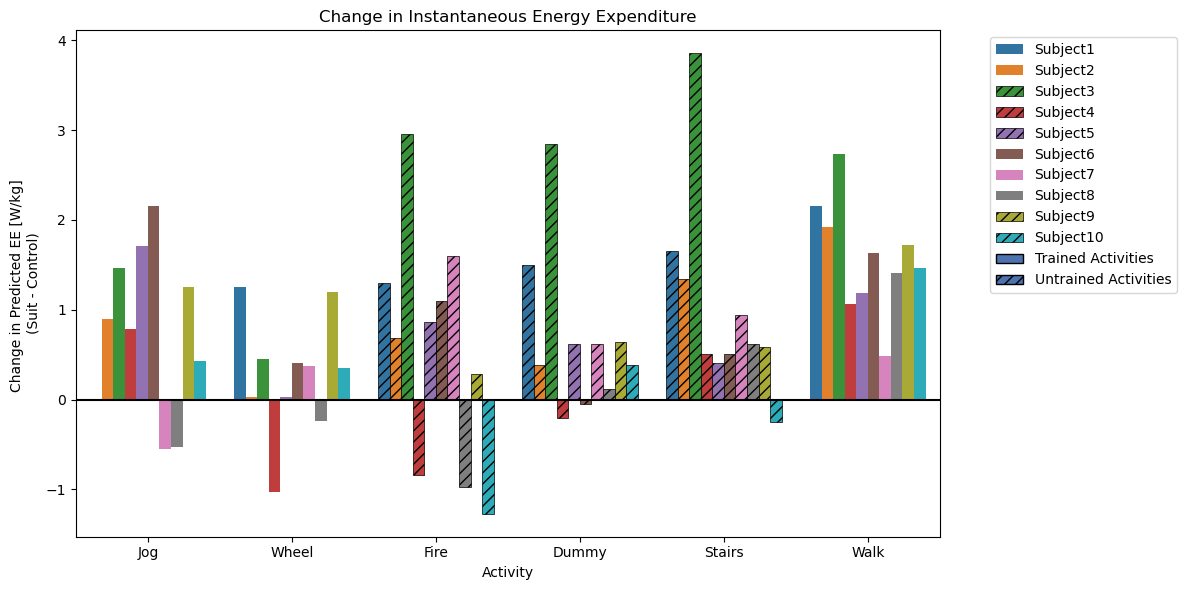

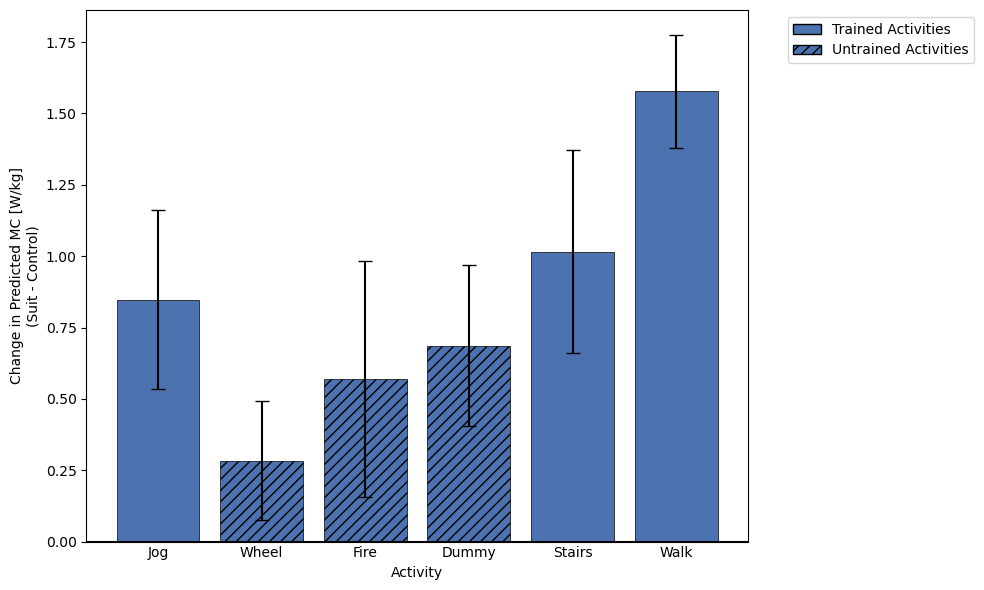

<Figure size 640x480 with 0 Axes>

In [4]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load the model trained on the original 9 subjects
model = joblib.load("ML_model_9subjects.pkl")

# Prepare the test data
new_data = trimmed_test.copy()
feature_cols = ["KE", "HR", "HRDeriv", "Weight", "right", "left"]
X_new = new_data[feature_cols]

# Generate predictions
new_data["Predicted_EE"] = model.predict(X_new)
new_data.to_csv("new_data.csv", index=False)

# Aggregate results
summary = (
    new_data
    .groupby(["Subject", "Activity", "Condition"])
    .agg(
        Mean_EE=("Predicted_EE", "mean"),
        Std_EE=("Predicted_EE", "std"),
        Samples=("Predicted_EE", "size")
    )
    .reset_index()
)

# Pivot to compare Suit vs. Control
comparison = summary.pivot_table(
    index=["Subject", "Activity"],
    columns="Condition",
    values="Mean_EE"
).reset_index()

# Calculate Delta and Percent Change
comparison["Delta"] = comparison["Suit"] - comparison["Control"]
comparison["Percent_Change"] = 100 * comparison["Delta"] / comparison["Control"]

# Data Cleaning: Drop Subject 1 Jog
comparison = comparison[~(
    (comparison["Subject"] == "Subject1") &
    (comparison["Activity"] == "Jog")
)]

# --- CATEGORICAL ORDERING: Force Subject10 to the end ---
# Get all unique subjects, remove Subject10 to sort the others, then append it
all_subjects = sorted([s for s in comparison["Subject"].unique() if s != "Subject10"])
subject_order = all_subjects + ["Subject10"]

# Set the 'Subject' column as a categorical type with the fixed order
comparison["Subject"] = pd.Categorical(comparison["Subject"], categories=subject_order, ordered=True)
comparison = comparison.sort_values(["Activity", "Subject"])

# --- Visualizing Individual Subject Deltas ---
activity_order = ["Jog", "Wheel", "Fire", "Dummy", "Stairs", "Walk"]
untrained_activities = ["Wheel", "Fire", "Dummy"]

plt.figure(figsize=(12, 6))
# 'hue_order' ensures the legend and bars follow the Subject10-at-the-end rule
ax = sns.barplot(
    data=comparison, 
    x="Activity", 
    y="Delta", 
    hue="Subject", 
    order=activity_order, 
    hue_order=subject_order
)

# Apply hatching to untrained activities
# Note: In hue-based barplots, patches are grouped by Subject (the hue)
n_subjects = len(subject_order)
for i, bar in enumerate(ax.patches):
    # Calculate which activity index this bar belongs to based on standard Seaborn patch ordering
    activity_idx = i % len(activity_order)
    activity = activity_order[activity_idx]
    
    if activity in untrained_activities:
        bar.set_hatch('///')
        bar.set_edgecolor('black')
        bar.set_linewidth(0.5)

plt.axhline(0, color="black")
plt.ylabel("Change in Predicted EE [W/kg] \n(Suit - Control)")
plt.title("Change in Instantaneous Energy Expenditure")

# Legend Construction
handles, labels = ax.get_legend_handles_labels()
trained_patch = Patch(facecolor="#4C72B0", edgecolor='black', label='Trained Activities')
untrained_patch = Patch(facecolor="#4C72B0", edgecolor='black', hatch='///', label='Untrained Activities')

handles.extend([trained_patch, untrained_patch])
labels.extend(['Trained Activities', 'Untrained Activities'])

plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Visualizing Averages ---
avg_comparison = (
    comparison
    .groupby("Activity")
    .agg(
        Mean_Delta=("Delta", "mean"),
        Std_Delta=("Delta", "std"),
        SEM=("Delta", lambda x: x.std() / np.sqrt(len(x))),
        N=("Delta", "size")
    )
    .reset_index()
)
avg_comparison["SEM"] = avg_comparison["Std_Delta"] / (avg_comparison["N"]**0.5)

# Enforce activity order for average plot
avg_comparison["Activity"] = pd.Categorical(avg_comparison["Activity"], categories=activity_order, ordered=True)
avg_comparison = avg_comparison.sort_values("Activity")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    avg_comparison["Activity"],
    avg_comparison["Mean_Delta"],
    yerr=avg_comparison["SEM"],   
    capsize=5, 
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

for bar, activity in zip(bars, avg_comparison["Activity"]):
    if activity in untrained_activities:
        bar.set_hatch("///")

ax.axhline(0, color="black")
ax.tick_params(axis='x', length=0)
ax.set_ylabel("Change in Predicted MC [W/kg]\n(Suit - Control)")
ax.set_xlabel("Activity")


ax.legend(handles=[trained_patch, untrained_patch], bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.savefig('instantaneous.png')

In [217]:
print(comparison)

Condition    Subject Activity   Control      Suit     Delta  Percent_Change
0           Subject1    Dummy  1.641825  3.139474  1.497649       91.218519
12          Subject2    Dummy  3.298001  3.677756  0.379755       11.514689
18          Subject3    Dummy  3.757509  6.601601  2.844092       75.690882
24          Subject4    Dummy  4.323525  4.123585 -0.199940       -4.624460
30          Subject5    Dummy  3.432250  4.048449  0.616199       17.953211
36          Subject6    Dummy  5.194465  5.148481 -0.045984       -0.885245
42          Subject7    Dummy  4.766983  5.388023  0.621041       13.027959
48          Subject8    Dummy  2.196526  2.319915  0.123389        5.617442
54          Subject9    Dummy  2.740222  3.380075  0.639852       23.350382
6          Subject10    Dummy  2.116311  2.503893  0.387582       18.314043
1           Subject1     Fire  1.873730  3.166404  1.292674       68.989321
13          Subject2     Fire  3.784122  4.464321  0.680199       17.975077
19          

In [185]:
print(avg_comparison)

  Activity  Mean_Delta  Std_Delta       SEM   N
2      Jog    0.848085   0.936043  0.312014   9
5    Wheel    0.283247   0.661310  0.209124  10
1     Fire    0.569358   1.310287  0.414349  10
0    Dummy    0.686363   0.891155  0.281808  10
3   Stairs    1.015892   1.125964  0.356061  10
4     Walk    1.576989   0.621901  0.196663  10


In [186]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fits the Linear Model
model_delta_ols = smf.ols(
    "Delta ~ 0 + C(Activity)", 
    data=comparison
).fit()

# --- OUTPUT SECTION ---
print("=" * 60)
print("LINEAR MODEL (OLS): Delta ~ 0 + C(Activity)")
print("=" * 60)
print(model_delta_ols.summary())



LINEAR MODEL (OLS): Delta ~ 0 + C(Activity)
                            OLS Regression Results                            
Dep. Variable:                  Delta   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     2.145
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0742
Time:                        21:31:32   Log-Likelihood:                -77.897
No. Observations:                  59   AIC:                             167.8
Df Residuals:                      53   BIC:                             180.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [150]:
import statsmodels
statsmodels.__version__

'0.14.4'

Spearman rho: -0.323
P-value: 0.362


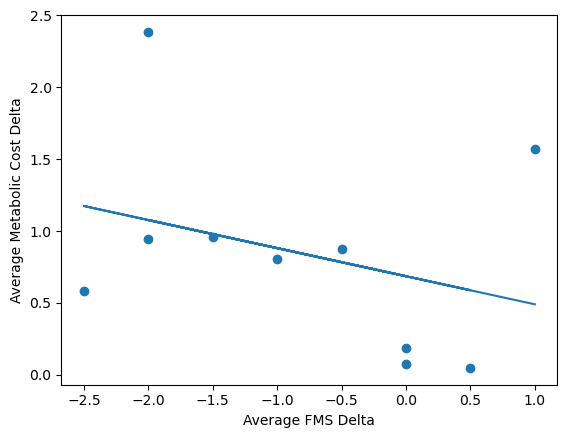

In [231]:
# functional mobility spearman
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

subjects = [f'Subject{i}' for i in range(1, 11)]
avg_mc_delta = [1.5691068, 0.8753515, 2.3855015, 0.0476345, 0.802242167, 0.957788667, 0.579922333, 0.071474833, 0.946908667, 0.184129667]
avg_fms_delta = [1, -0.5, -2, 0.5, -1, -1.5, -2.5, 0, -2, 0]

df = pd.DataFrame({
    'Subject': subjects,
    'Avg_MC_Delta': avg_mc_delta,
    'Avg_FMS_Delta': avg_fms_delta
})

# Spearman correlation
rho, p_value = stats.spearmanr(df['Avg_FMS_Delta'], df['Avg_MC_Delta'])

print(f'Spearman rho: {rho:.3f}')
print(f'P-value: {p_value:.3f}')

# Scatter plot
plt.figure()
plt.scatter(df['Avg_FMS_Delta'], df['Avg_MC_Delta'])

# Fit linear regression line (for visualization)
slope, intercept, r, p, std_err = stats.linregress(df['Avg_FMS_Delta'], df['Avg_MC_Delta'])
x_vals = np.array(df['Avg_FMS_Delta'])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals)

plt.xlabel('Average FMS Delta')
plt.ylabel('Average Metabolic Cost Delta')


plt.show()

In [232]:
# task workload spearman
import pandas as pd

subjects = [f'Subject{i}' for i in range(1, 11)]
avg_mc_delta = [1.5691068, 0.8753515, 2.3855015, 0.0476345, 0.802242167, 0.957788667, 0.579922333, 0.071474833, 0.946908667, 0.184129667]
avg_nasa_delta = [47, 34, 58, 14, 40, 31, 24, 55, 26, 33]

df = pd.DataFrame({
    'Subject': subjects,
    'Avg_MC_Delta': avg_mc_delta,
    'Avg_nasa_Delta': avg_nasa_delta
})

from scipy import stats

rho, p_value = stats.spearmanr(df['Avg_nasa_Delta'], df['Avg_MC_Delta'])

print(f'Spearman rho: {rho:.3f}')
print(f'P-value: {p_value:.3f}')

Spearman rho: 0.430
P-value: 0.214


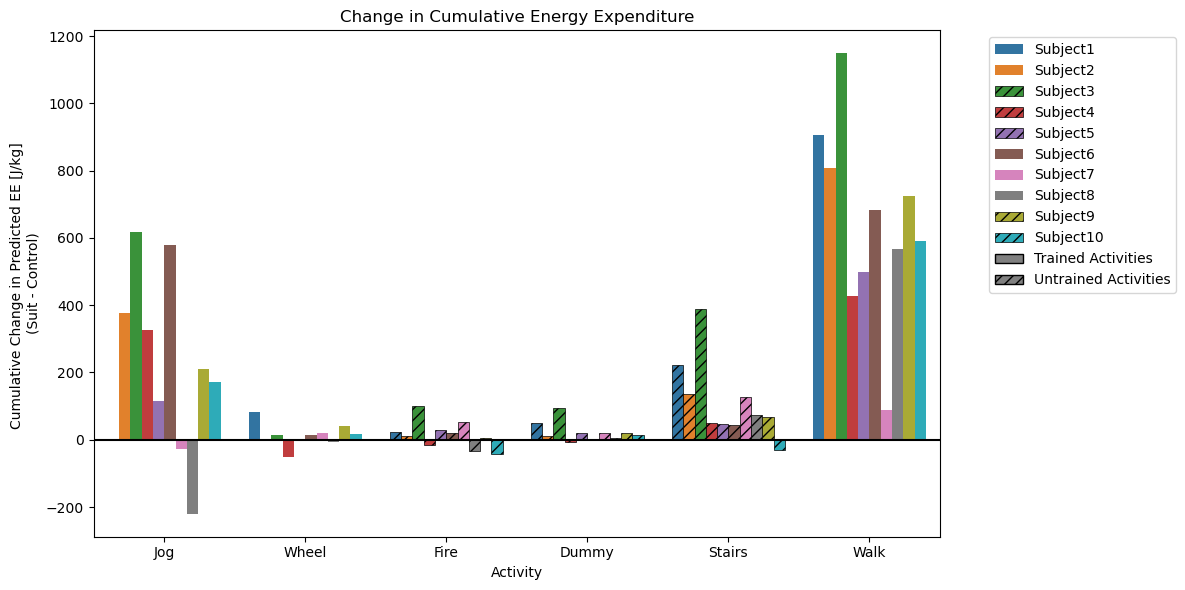

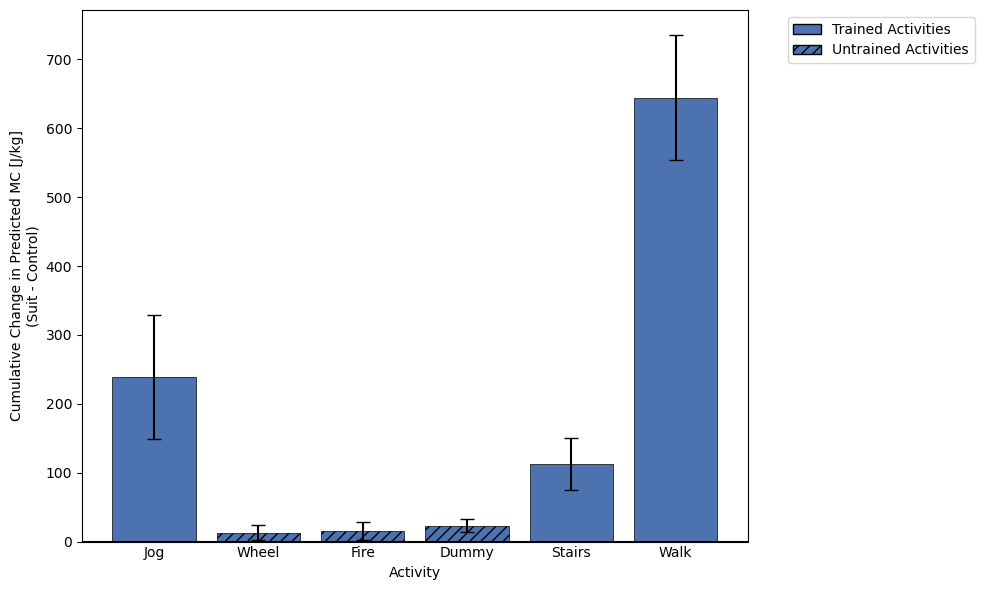

<Figure size 640x480 with 0 Axes>

In [5]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load the full model
model = joblib.load("ML_model_full.pkl")
new_data = trimmed_test.copy()

# Features for prediction
feature_cols = ["KE", "HR", "HRDeriv", "Weight", "right", "left"]
X_new = new_data[feature_cols]

# Predict cumulative MC
new_data["Predicted_EE"] = model.predict(X_new)
new_data["EE_energy"] = new_data["Predicted_EE"] * 15

# Aggregate Cumulative Energy
summary = (
    new_data
    .groupby(["Subject", "Activity", "Condition"])
    .agg(
        Cumulative_EE=("EE_energy", "sum"),
        Samples=("EE_energy", "size")
    )
    .reset_index()
)

# Pivot for comparison
comparison = summary.pivot_table(
    index=["Subject", "Activity"],
    columns="Condition",
    values="Cumulative_EE"
).reset_index()

# Calculate Delta
comparison["Delta"] = comparison["Suit"] - comparison["Control"]
comparison["Percent_Change"] = 100 * comparison["Delta"] / comparison["Control"]

# Data Cleaning: Filter out Subject 1 Jog
comparison = comparison[~(
    (comparison["Subject"] == "Subject1") &
    (comparison["Activity"] == "Jog")
)]

# --- CATEGORICAL ORDERING: ----
all_subjects = sorted([s for s in comparison["Subject"].unique() if s != "Subject10"])
subject_order = all_subjects + ["Subject10"]

comparison["Subject"] = pd.Categorical(comparison["Subject"], categories=subject_order, ordered=True)
comparison = comparison.sort_values(["Activity", "Subject"])

# --- Plotting Configuration ---
activity_order = ["Jog", "Wheel", "Fire", "Dummy", "Stairs", "Walk"]
untrained_activities = ["Wheel", "Fire", "Dummy"]

# --- Individual Subject Plot ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=comparison, 
    x="Activity", 
    y="Delta", 
    hue="Subject", 
    order=activity_order,
    hue_order=subject_order  
)

# Add hatching to untrained activities
for i, bar in enumerate(ax.patches):
    activity_idx = i % len(activity_order)
    activity = activity_order[activity_idx]
    
    if activity in untrained_activities:
        bar.set_hatch('///')
        bar.set_edgecolor('black')
        bar.set_linewidth(0.5)

plt.axhline(0, color="black")
plt.ylabel("Cumulative Change in Predicted EE [J/kg] \n(Suit - Control)")
plt.title("Change in Cumulative Energy Expenditure")

# Legend Construction
handles, labels = ax.get_legend_handles_labels()
trained_patch = Patch(facecolor='gray', edgecolor='black', label='Trained Activities')
untrained_patch = Patch(facecolor='gray', edgecolor='black', hatch='///', label='Untrained Activities')

handles.extend([trained_patch, untrained_patch])
labels.extend(['Trained Activities', 'Untrained Activities'])

plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Average Across Subjects Plot ---
avg_comparison = (
    comparison
    .groupby("Activity")
    .agg(
        Mean_Delta=("Delta", "mean"),
        SEM=("Delta", lambda x: x.std() / np.sqrt(len(x)))
    )
    .reset_index()
)

# Enforce activity order for average chart
avg_comparison["Activity"] = pd.Categorical(avg_comparison["Activity"], categories=activity_order, ordered=True)
avg_comparison = avg_comparison.sort_values("Activity")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    avg_comparison["Activity"],
    avg_comparison["Mean_Delta"],
    yerr=avg_comparison["SEM"],   
    capsize=5,                   
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

# Apply hatching to average bars
for bar, activity in zip(bars, avg_comparison["Activity"]):
    if activity in untrained_activities:
        bar.set_hatch("///")

ax.axhline(0, color="black")
ax.tick_params(axis='x', length=0)
ax.set_ylabel("Cumulative Change in Predicted MC [J/kg]\n(Suit - Control)")
ax.set_xlabel("Activity")


trained_patch_avg = Patch(facecolor="#4C72B0", edgecolor="black", label="Trained Activities")
untrained_patch_avg = Patch(facecolor="#4C72B0", edgecolor="black", hatch="///", label="Untrained Activities")
ax.legend(handles=[trained_patch_avg, untrained_patch_avg], bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
plt.savefig('cumulative.png')

In [142]:
print(avg_comparison)

  Activity  Mean_Delta
2      Jog  239.092628
5    Wheel   13.184150
1     Fire   15.050564
0    Dummy   23.137983
3   Stairs  112.699424
4     Walk  644.260609


In [9]:
import statsmodels.formula.api as smf

model_delta = smf.ols(
    "Delta ~ 0 + C(Activity)",
    data=comparison
).fit()

print("=" * 60)
print("OLS MODEL: Delta ~ 0 + C(Activity)")
print("=" * 60)
print(model_delta.summary())

print("\n" + "=" * 60)
print("PPE EFFECT BY ACTIVITY")
print("=" * 60)

for param in model_delta.params.index:
    coef = model_delta.params[param]
    pval = model_delta.pvalues[param]
    ci = model_delta.conf_int().loc[param]
    sig = "" if pval < 0.05 else ""
    print(f"  {param}: {coef:.4f} W/kg, p = {pval:.4f} {sig}")

OLS MODEL: Delta ~ 0 + C(Activity)
                            OLS Regression Results                            
Dep. Variable:                  Delta   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     21.54
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.06e-11
Time:                        16:01:41   Log-Likelihood:                -382.74
No. Observations:                  59   AIC:                             777.5
Df Residuals:                      53   BIC:                             789.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [187]:
# Monte Carlo uncertainty 
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model = joblib.load("ML_model_9subjects.pkl")

def estimation_uncertainty(model, X_test, n_simulations=1000, noise_std=0.05):
    X_test_array = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    n_samples = X_test_array.shape[0]
    n_features = X_test_array.shape[1]
    
    all_predictions = np.zeros((n_simulations, n_samples))
    
    feature_stds = np.std(X_test_array, axis=0)
    
    for i in range(n_simulations):
        noise = np.random.normal(0, noise_std, (n_samples, n_features)) * feature_stds
        X_noisy = X_test_array + noise
        
        predictions = model.predict(X_noisy)
        all_predictions[i, :] = predictions
    
    mean_predictions = np.mean(all_predictions, axis=0)
    std_predictions = np.std(all_predictions, axis=0)
    
    return mean_predictions, std_predictions, all_predictions

tune_subject = 0 
mask_test = subjects != tune_subject

X_test = X[mask_test].reset_index(drop=True)
y_test = y[mask_test].reset_index(drop=True)

print(f"Test set size: {len(X_test)} samples")

mean_pred, std_pred, all_pred = estimation_uncertainty(
    model, X_test, n_simulations=1000, noise_std=0.05
)


print(f"Average uncertainty: {np.mean(std_pred):.3f}")
print(f"Max uncertainty: {np.max(std_pred):.3f}")
print(f"Min uncertainty: {np.min(std_pred):.3f}")

Test set size: 4341 samples
Average uncertainty: 0.103
Max uncertainty: 0.111
Min uncertainty: 0.095


In [188]:
# Bootstrap uncertainty
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
from sklearn.base import clone
warnings.filterwarnings("ignore")

# Load model and dataframe
model = joblib.load("ML_model_9subjects.pkl")
merged_df = joblib.load("merged_df_train.pkl")

# Drop Subject01
merged_df = merged_df[merged_df["Subject"] != "Subject01"].reset_index(drop=True)
print(merged_df.columns)

# Define features and target
X = merged_df.drop(columns=["Subject", "Activity", "EE"])  
y = merged_df["EE"]

# Bootstrap function
def bootstrap_uncertainty(model, X_train, y_train, X_test, n_bootstrap=1000, random_state=42):

    Xtr = X_train.copy()
    ytr = y_train.copy()
    Xte = X_test.copy()
    
    n_train = Xtr.shape[0]
    n_test = Xte.shape[0]

    all_predictions = np.zeros((n_bootstrap, n_test))
    rng = np.random.default_rng(random_state)

    for i in range(n_bootstrap):
        idx = rng.choice(n_train, size=n_train, replace=True)
        
        if isinstance(Xtr, pd.DataFrame):
            X_boot = Xtr.iloc[idx]
        else:
            X_boot = Xtr[idx]
        
        y_boot = ytr.iloc[idx] if isinstance(ytr, pd.Series) else ytr[idx]

        model_i = clone(model)
        model_i.fit(X_boot, y_boot)

        all_predictions[i, :] = model_i.predict(Xte)

    mean_predictions = np.mean(all_predictions, axis=0)
    std_predictions = np.std(all_predictions, axis=0)

    return mean_predictions, std_predictions, all_predictions

# Make sure subjects array exists
subjects = merged_df["Subject"].reset_index(drop=True)

# Leave-one-subject-out split
tune_subject = subjects.unique()[0]  # pick first remaining subject
mask_train = subjects != tune_subject
mask_test  = subjects == tune_subject

X_train = X[mask_train].reset_index(drop=True)
y_train = y[mask_train].reset_index(drop=True)
X_test  = X[mask_test].reset_index(drop=True)
y_test  = y[mask_test].reset_index(drop=True)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)} samples")

# Run bootstrap
mean_pred, std_pred, all_pred = bootstrap_uncertainty(
    model,
    X_train,
    y_train,
    X_test,
    n_bootstrap=1000
)

print(f"Average uncertainty: {np.mean(std_pred):.3f}")
print(f"Max uncertainty: {np.max(std_pred):.3f}")
print(f"Min uncertainty: {np.min(std_pred):.3f}")


Index(['Subject', 'Activity', 'Time', 'KE', 'HR', 'HRDeriv', 'EE', 'Weight',
       'rsol', 'rbf', 'lsol', 'lbf'],
      dtype='object')
Train set size: 3864
Test set size: 477 samples
Average uncertainty: 0.049
Max uncertainty: 0.164
Min uncertainty: 0.023


In [189]:
# used to calculate total uncertainty
import math

bias = -0.0558
sigma_mc = 0.103
sigma_bs = 0.049 

u_combined = math.sqrt(sigma_mc**2 + sigma_bs**2)

U_95 = 1.96 * u_combined

print(f"Combined Standard Uncertainty: {u_combined:.4f}")
print(f"Expanded Uncertainty (95% CI): ±{U_95:.4f}")
print(f"Final Calibration: Adjusted_EE = Prediction + {abs(bias):.4f} ± {U_95:.4f}")

Combined Standard Uncertainty: 0.1141
Expanded Uncertainty (95% CI): ±0.2236
Final Calibration: Adjusted_EE = Prediction + 0.0558 ± 0.2236
